# Lightweight Multimodal Landslide Classification
### Sentinel-1 SAR + Sentinel-2 Optical · MobileNetV3-Small · Baseline Experiments E1–E3

**Task:** binary classification of 64 × 64 satellite patches — `0 = No Landslide`, `1 = Landslide`.

**Research question:** can a *lightweight* multimodal model (≈ 2 M parameters) get close to the accuracy of a large transformer + GBDT ensemble (reference F1 ≈ 0.919), while staying small and fast enough for edge deployment?

| Item | Value |
|---|---|
| Input tensor | `64 × 64 × 12` stored as `.npy` |
| Sentinel-2 (optical) | channels 0–3 → Red, Green, Blue, NIR |
| Sentinel-1 (SAR) | channels 4–11 → descending / ascending VV, VH and their difference images |
| Samples | 7,147 (5,892 No Landslide · 1,255 Landslide ≈ 82.4 % / 17.6 %) |
| Split | stratified 80 / 20, `random_state=42` → 5,717 train / 1,430 val |

#### Experiments in this notebook

| ID | Model | Input | Params | Purpose |
|---|---|---|---|---|
| **E1** | MobileNetV3-Small | S2 only | ≈ 1.00 M | optical-only baseline |
| **E2** | MobileNetV3-Small | S1 only | ≈ 1.00 M | SAR-only baseline |
| **E3** | 2 × MobileNetV3-Small + late fusion | S1 + S2 | ≈ 2.00 M | does combining modalities help? |

All three use random initialisation (`weights=None`), AdamW (lr 1e-3, wd 1e-4), a class-weighted BCE loss, 15 epochs and a fixed 0.5 threshold, so the comparison is controlled. The **best epoch is chosen by validation F1**.

#### Notebook map
1. **Data inspection** — CSV, file mapping, tensor statistics, normalisation
2. **Environment check** — PyTorch / CUDA / MobileNetV3 smoke test
3. **Data pipeline** — `Dataset`, split, `DataLoader`
4. **E1** — Sentinel-2-only model
5. **E2** — Sentinel-1-only model
6. **E3** — Multimodal fusion model
7. **Results summary and next step (E4)**

## Part 1 · Data inspection
### 1.1 Imports and configuration
Set the random seed and the paths to the dataset. If your extracted data lives somewhere else, **edit only `DATA_ROOT`** — everything else is derived from it.

Expected layout:
```text
data/
├── Train.csv          # columns: ID, label
└── train_data/        # one <ID>.npy file per sample
```

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

SEED = 42
np.random.seed(SEED)

# Change these paths if your extracted dataset has a different structure.
DATA_ROOT = Path("./data")
TRAIN_CSV = DATA_ROOT / "Train.csv"
TRAIN_DATA_DIR = DATA_ROOT / "train_data"

print("DATA_ROOT:", DATA_ROOT.resolve())
print("TRAIN_CSV:", TRAIN_CSV)
print("TRAIN_DATA_DIR:", TRAIN_DATA_DIR)

DATA_ROOT: C:\Users\Aditya\Desktop\MTP\data
TRAIN_CSV: data\Train.csv
TRAIN_DATA_DIR: data\train_data


### 1.2 Load `Train.csv`
`Train.csv` maps each sample `ID` to its binary `label`. Check that the shape and column names look right before touching any image data.

In [2]:
train_df = pd.read_csv(TRAIN_CSV)
print("Shape:", train_df.shape)
print("Columns:", train_df.columns.tolist())
display(train_df.head())

Shape: (7147, 2)
Columns: ['ID', 'label']


,ID,label
0,ID_HUD1ST,1
1,ID_KGE2HY,1
2,ID_VHV9BL,1
3,ID_ZT0VEJ,0
4,ID_5NFXVY,0


### 1.3 Data quality and class balance
Check for missing values and duplicate rows/IDs, then look at the class distribution.

**What to expect:** no missing values or duplicates, and a strong imbalance (≈ 82 % No Landslide vs ≈ 18 % Landslide). Because of this imbalance, **accuracy is misleading** — we track F1, precision, recall and ROC-AUC, and use a positively-weighted loss later on.

In [3]:
print("Missing values:")
display(train_df.isna().sum())
print("Duplicate rows:", train_df.duplicated().sum())
print("Duplicate IDs:", train_df["ID"].duplicated().sum())
print("\nClass distribution:")
display(train_df["label"].value_counts().sort_index())
print("\nClass proportions:")
display(train_df["label"].value_counts(normalize=True).sort_index())

Missing values:


ID       0
label    0
dtype: int64

Duplicate rows: 0
Duplicate IDs: 0

Class distribution:


label
0    5892
1    1255
Name: count, dtype: int64


Class proportions:


label
0    0.824402
1    0.175598
Name: proportion, dtype: float64

### 1.4 Locate the `.npy` files
Count the `.npy` tensors on disk. The number should match the number of rows in `Train.csv` (7,147).

In [4]:
if TRAIN_DATA_DIR.exists():
    npy_files = sorted(TRAIN_DATA_DIR.rglob("*.npy"))
    print("Number of .npy files:", len(npy_files))
    for p in npy_files[:10]: print(p)
else:
    print("Directory not found:", TRAIN_DATA_DIR.resolve())
    print("Extract train_data.zip and update TRAIN_DATA_DIR if necessary.")

Number of .npy files: 7147
data\train_data\ID_005GY8.npy
data\train_data\ID_007CM8.npy
data\train_data\ID_0082FF.npy
data\train_data\ID_00CT09.npy
data\train_data\ID_00KYD0.npy
data\train_data\ID_00XNFF.npy
data\train_data\ID_01199V.npy
data\train_data\ID_0192W8.npy
data\train_data\ID_01BKNN.npy
data\train_data\ID_01KO54.npy


### 1.5 Verify the ID → file mapping
Each `ID` must resolve to **exactly one** `.npy` file. The helper below raises an error if an ID matches more than one file and returns `None` if it matches none.

In [5]:
def find_npy_for_id(sample_id, data_dir=TRAIN_DATA_DIR):
    candidates = list(Path(data_dir).rglob(f"{sample_id}.npy"))
    if len(candidates) == 1: return candidates[0]
    if len(candidates) > 1: raise RuntimeError(f"Multiple files found for {sample_id}: {candidates}")
    return None

example_id = train_df.iloc[0]["ID"]
example_path = find_npy_for_id(example_id)
print("Example ID:", example_id)
print("Matching file:", example_path)

Example ID: ID_HUD1ST
Matching file: data\train_data\ID_HUD1ST.npy


### 1.6 Inspect one raw tensor
Load a single sample and check its shape (`64 × 64 × 12`), dtype, value range, and whether it contains NaN / Inf values. Raw satellite values are **not** on a 0–1 scale, which is why normalisation is needed.

In [6]:
if example_path is not None:
    sample = np.load(example_path)
    print("Shape:", sample.shape)
    print("Dtype:", sample.dtype)
    print("Min:", np.nanmin(sample))
    print("Max:", np.nanmax(sample))
    print("Mean:", np.nanmean(sample))
    print("NaN count:", np.isnan(sample).sum())
    print("Inf count:", np.isinf(sample).sum())
else:
    print("No matching .npy file found.")

Shape: (64, 64, 12)
Dtype: float64
Min: -50.60046620592013
Max: 6372.0
Mean: 746.1626572312028
NaN count: 0
Inf count: 0


### 1.7 Per-channel statistics
The starter notebook documents 12 channels:

| Channels | Modality | Content |
|---|---|---|
| 0–3 | Sentinel-2 | Red, Green, Blue, NIR |
| 4–11 | Sentinel-1 | Descending VV, VH, Diff-VV, Diff-VH · Ascending VV, VH, Diff-VV, Diff-VH |

Verify on the real tensor (min / max / mean / std per channel) instead of trusting the documentation blindly. Optical and SAR channels usually have very different value ranges, which is another reason a per-channel normalisation is required.

In [7]:
if example_path is not None and sample.ndim == 3:
    rows=[]
    for c in range(sample.shape[-1]):
        ch=sample[...,c]
        rows.append({"channel":c,"min":float(ch.min()),"max":float(ch.max()),"mean":float(ch.mean()),"std":float(ch.std())})
    display(pd.DataFrame(rows))

,channel,min,max,mean,std
0,0,1286.000000,2786.000000,1569.305908,189.202911
1,1,1385.000000,3006.000000,1751.834229,211.081488
2,2,1255.000000,3242.000000,1527.176758,253.367521
3,3,1910.000000,6372.000000,4164.684326,658.590286
4,4,-21.888342,4.489973,-3.390316,4.299815
5,5,-29.269530,-1.802792,-9.956253,4.180085
6,6,-7.648527,6.668898,0.366443,1.983820
7,7,-9.375606,6.879133,0.387364,2.180651
8,8,-48.097597,-1.161561,-20.120568,7.755605
9,9,-50.600466,-7.848943,-25.408458,8.365997


### 1.8 Reference normalisation
The starter notebook applies **per-image, per-channel min–max scaling**:

$$x_{norm} = \frac{x - \min(x)}{\max(x) - \min(x) + \varepsilon}, \qquad \varepsilon = 10^{-5}$$

The min/max are computed over the spatial dimensions of *each channel of each image*. We keep this exact preprocessing for E1–E3 so that later experiments (E4+) are compared against an unchanged data pipeline.

> **Note:** this scaling discards absolute intensity information (every image is stretched to [0, 1]). Alternatives such as dataset-level standardisation can be tested as a separate experiment later.

In [8]:
def normalize_per_channel(image, eps=1e-5):
    image=image.astype(np.float32, copy=False)
    mn=image.min(axis=(0,1),keepdims=True)
    mx=image.max(axis=(0,1),keepdims=True)
    return (image-mn)/(mx-mn+eps)

if example_path is not None:
    normalized_sample=normalize_per_channel(sample)
    print("Normalized min:", normalized_sample.min())
    print("Normalized max:", normalized_sample.max())
    print("Normalized dtype:", normalized_sample.dtype)

Normalized min: 0.0
Normalized max: 1.0
Normalized dtype: float32


##  Checkpoint 1 — Data verification
Before writing any model code, the following must hold:

- [x] `Train.csv` loads; columns are `ID`, `label`
- [x] every ID maps to exactly one `.npy` file
- [x] tensor shape is `64 × 64 × 12` with no NaN / Inf
- [x] channel statistics match the documented layout
- [x] normalisation returns float32 values in [0, 1]

**Next:** set up the PyTorch environment, then build a lazy `Dataset` / `DataLoader` and verify one batch.

## Part 2 · Environment check
### 2.1 Install PyTorch (CUDA 12.4 build)
Run this cell **once**, then restart the kernel if prompted. Skip it if PyTorch with CUDA is already installed.

In [13]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu124
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/6.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.8/6.1 MB 5.6 MB/s eta 0:00:01
   -------------------------------- ------- 5.0/6.1 MB 15.1 MB/s eta 0:00:01
   ---------------------------------------- 6.1/6.1 MB 14.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.5 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.5 GB 7.6 MB/s eta 0:05:33
   ---------------------------------------- 0.0/2.5 GB 21.3 MB/s eta 0:01:59
   ---------------------------------------- 0.0/2.5 GB 20.7 MB/s eta 0:02:02
   ---------------------------------------- 0.0/2.5 GB 20.3 MB/s eta 0:02:05
   --------------------------------------

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/2.5 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.5 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.5 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.5 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.5 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.5 GB 479.2 kB/s eta 1:28:03
   ---------------------------------------- 0.0/2.5 GB 479.2 kB/s eta 1:28:03
   ---------------------------------------- 0.0/2.5 GB 479.2 kB/s eta 1:28:03
   ---------------------------------------- 0.0/2.5 GB 441.7 kB/s eta 1:35:32
   ---------------------------------------- 0.0/2.5 GB 441.7 kB/s eta 1:35:32


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, which is not installed.


### 2.2 Verify library versions and CUDA
Print the versions of the main libraries and check that PyTorch can see the GPU. Record these in your experiment log for reproducibility.

In [9]:
import sys
import numpy as np
import pandas as pd
import sklearn
import torch
import torchvision

print("=" * 60)
print("PYTHON ENVIRONMENT")
print("=" * 60)

print("Python       :", sys.version)
print("NumPy        :", np.__version__)
print("Pandas       :", pd.__version__)
print("Scikit-learn :", sklearn.__version__)
print("PyTorch      :", torch.__version__)
print("Torchvision  :", torchvision.__version__)

print("\n" + "=" * 60)
print("CUDA")
print("=" * 60)

print("PyTorch CUDA version :", torch.version.cuda)
print("CUDA available       :", torch.cuda.is_available())
print("CUDA device count    :", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU                  :", torch.cuda.get_device_name(0))
    print("GPU capability       :", torch.cuda.get_device_capability(0))
    print("cuDNN version        :", torch.backends.cudnn.version())

PYTHON ENVIRONMENT
Python       : 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
NumPy        : 1.26.4
Pandas       : 2.2.2
Scikit-learn : 1.5.1
PyTorch      : 2.6.0+cu124
Torchvision  : 0.21.0+cu124

CUDA
PyTorch CUDA version : 12.4
CUDA available       : True
CUDA device count    : 1
GPU                  : NVIDIA GeForce RTX 3050 Laptop GPU
GPU capability       : (8, 6)
cuDNN version        : 90100


### 2.3 GPU computation test
Run a small matrix multiplication on the GPU to confirm that CUDA works end-to-end, not just that it is detected.

In [10]:
print("=" * 60)
print("GPU COMPUTATION TEST")
print("=" * 60)

if torch.cuda.is_available():

    device = torch.device("cuda")

    x = torch.randn(2000, 2000, device=device)
    y = torch.randn(2000, 2000, device=device)

    z = x @ y

    torch.cuda.synchronize()

    print("Tensor device :", z.device)
    print("Tensor shape  :", z.shape)
    print("GPU test      : SUCCESS")

else:
    print("GPU test      : FAILED — CUDA is not available")

GPU COMPUTATION TEST
Tensor device : cuda:0
Tensor shape  : torch.Size([2000, 2000])
GPU test      : SUCCESS


### 2.4 MobileNetV3-Small smoke test
Create an untrained `mobilenet_v3_small`, count its parameters, and run a dummy `224 × 224` RGB batch through it on the GPU. This only confirms that the model and hardware work; it is not part of the experiments.

In [11]:
from torchvision.models import mobilenet_v3_small

model = mobilenet_v3_small(weights=None)

print("MobileNetV3-Small loaded successfully")
print("Parameters:", sum(p.numel() for p in model.parameters()))

MobileNetV3-Small loaded successfully
Parameters: 2542856


In [12]:
import torch
from torchvision.models import mobilenet_v3_small

device = torch.device("cuda")

model = mobilenet_v3_small(weights=None).to(device)

x = torch.randn(4, 3, 224, 224).to(device)

with torch.no_grad():
    y = model(x)

print("Input :", x.shape, x.device)
print("Output:", y.shape, y.device)

Input : torch.Size([4, 3, 224, 224]) cuda:0
Output: torch.Size([4, 1000]) cuda:0


## Part 3 · PyTorch data pipeline
### 3.1 `LandslideDataset`
The dataset loads samples **lazily** (one `.npy` per `__getitem__`), so the full dataset never has to fit in memory. For each sample it:

1. loads the `64 × 64 × 12` array,
2. applies the per-channel min–max normalisation,
3. converts `H × W × C` → `C × H × W`,
4. splits it into **S2** (`channels 0:4`) and **S1** (`channels 4:12`),
5. returns `(s2, s1, label)`.

> The next code cell is an earlier draft with a `return_modalities` flag. It is **superseded by the final version a few cells below**, which is the one used for all experiments.

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


class LandslideDataset(Dataset):
    def __init__(self, dataframe, data_dir, return_modalities=True):
        self.df = dataframe.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.return_modalities = return_modalities

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        sample_id = row["ID"]
        label = int(row["label"])

        # Load .npy
        path = self.data_dir / f"{sample_id}.npy"
        image = np.load(path)

        # Normalize using the reference preprocessing
        image = normalize_per_channel(image)

        # HWC → CHW
        image = np.transpose(image, (2, 0, 1))

        # Convert to PyTorch tensor
        image = torch.from_numpy(image).float()

        label = torch.tensor(label, dtype=torch.float32)

        if self.return_modalities:

            # Sentinel-2: channels 0–3
            s2 = image[0:4]

            # Sentinel-1: channels 4–11
            s1 = image[4:12]

            return s2, s1, label

        return image, label

#### Final `LandslideDataset` (used in all experiments)
Same logic as the draft above, but it always returns the three-part tuple `(s2, s1, label)`. This keeps the training loops identical for every experiment: unimodal models simply ignore the modality they do not need.

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


class LandslideDataset(Dataset):

    def __init__(self, dataframe, data_dir):
        self.df = dataframe.reset_index(drop=True)
        self.data_dir = Path(data_dir)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        sample_id = row["ID"]
        label = int(row["label"])

        # Load the satellite patch
        path = self.data_dir / f"{sample_id}.npy"
        image = np.load(path)

        # Reference preprocessing
        image = normalize_per_channel(image)

        # HWC → CHW
        image = np.transpose(image, (2, 0, 1))

        # Convert to float32 PyTorch tensor
        image = torch.from_numpy(image).float()

        # Split modalities
        # Sentinel-2: channels 0–3
        s2 = image[0:4]

        # Sentinel-1: channels 4–11
        s1 = image[4:12]

        label = torch.tensor(label, dtype=torch.float32)

        return s2, s1, label

### 3.2 Train / validation split
Stratified 80 / 20 split with `random_state=42`, identical to the reference notebook. Stratification keeps the class ratio (≈ 17.6 % landslide) the same in both subsets, which matters for such an imbalanced dataset.

In [15]:
train_split, val_split = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["label"]
)

print("Training samples  :", len(train_split))
print("Validation samples:", len(val_split))

print("\nTraining distribution:")
print(train_split["label"].value_counts())

print("\nValidation distribution:")
print(val_split["label"].value_counts())

Training samples  : 5717
Validation samples: 1430

Training distribution:
label
0    4713
1    1004
Name: count, dtype: int64

Validation distribution:
label
0    1179
1     251
Name: count, dtype: int64


### 3.3 Create the dataset objects
Wrap the two splits in `LandslideDataset`. No data is read from disk yet.

In [16]:
train_dataset = LandslideDataset(
    train_split,
    TRAIN_DATA_DIR
)

val_dataset = LandslideDataset(
    val_split,
    TRAIN_DATA_DIR
)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))

Train dataset: 5717
Val dataset  : 1430


### 3.4 Create the `DataLoader`s
Batch size 32. The training loader shuffles every epoch; the validation loader does not. `num_workers=0` is used for compatibility on Windows — raise it if data loading becomes the bottleneck.

In [17]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

### 3.5 Sanity-check one batch
Load a single batch and verify the shapes and ranges:

| Tensor | Expected shape | Expected range |
|---|---|---|
| S2 | `[32, 4, 64, 64]` | 0 → 1 |
| S1 | `[32, 8, 64, 64]` | 0 → 1 |
| Labels | `[32]` | 0 or 1 |

In [18]:
s2_batch, s1_batch, labels = next(iter(train_loader))

print("S2 batch shape :", s2_batch.shape)
print("S1 batch shape :", s1_batch.shape)
print("Labels shape   :", labels.shape)

print("\nDtypes:")
print("S2     :", s2_batch.dtype)
print("S1     :", s1_batch.dtype)
print("Labels :", labels.dtype)

print("\nRanges:")
print("S2:", s2_batch.min().item(), "→", s2_batch.max().item())
print("S1:", s1_batch.min().item(), "→", s1_batch.max().item())

print("\nLabels:")
print(labels[:20])

S2 batch shape : torch.Size([32, 4, 64, 64])
S1 batch shape : torch.Size([32, 8, 64, 64])
Labels shape   : torch.Size([32])

Dtypes:
S2     : torch.float32
S1     : torch.float32
Labels : torch.float32

Ranges:
S2: 0.0 → 1.0
S1: 0.0 → 0.9999997615814209

Labels:
tensor([1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1.])


## Part 4 · E1 — Sentinel-2-only baseline
**Question:** how much can optical data alone (R, G, B, NIR) tell us about landslides with a ~1 M-parameter model?

```text
S2 (4 × 64 × 64) → MobileNetV3-Small → 576 features → Linear(576→128) → Hardswish → Dropout(0.2) → Linear(128→1) → logit
```

Two changes are made to the stock torchvision MobileNetV3-Small:
- the **first convolution** accepts 4 channels instead of 3,
- the **classifier head** outputs a single logit instead of 1,000 ImageNet classes.

The model is randomly initialised (`weights=None`); pretrained weights are the subject of E4.

In [19]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small


class S2MobileNetV3(nn.Module):

    def __init__(self):
        super().__init__()

        # Load MobileNetV3-Small architecture
        self.backbone = mobilenet_v3_small(weights=None)

        # --------------------------------------------------
        # Modify first convolution:
        # Original: 3 input channels
        # Our S2:   4 input channels
        # --------------------------------------------------

        old_conv = self.backbone.features[0][0]

        self.backbone.features[0][0] = nn.Conv2d(
            in_channels=4,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            dilation=old_conv.dilation,
            groups=old_conv.groups,
            bias=False
        )

        # --------------------------------------------------
        # Replace ImageNet classifier
        # Original output: 1000 classes
        # Our output: 1 binary logit
        # --------------------------------------------------

        in_features = self.backbone.classifier[0].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.Hardswish(),
            nn.Dropout(p=0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.backbone(x)

### 4.1 Instantiate the model
Move the model to the GPU (or CPU if no GPU is available) and print its architecture.

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = S2MobileNetV3().to(device)

print("Device:", device)
print(model)

Device: cuda
S2MobileNetV3(
  (backbone): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
   

### 4.2 Parameter count
E1 should have ≈ 1.0 M parameters. This is the reference size for a single lightweight branch.

In [21]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Total parameters     : 1,001,137
Trainable parameters : 1,001,137


### 4.3 Forward-pass test
Pass one S2 batch through the untrained model. The output should have shape `[32, 1]` (one logit per sample).

In [22]:
model.eval()

s2_batch = s2_batch.to(device)

with torch.no_grad():
    output = model(s2_batch)

print("Input shape :", s2_batch.shape)
print("Output shape:", output.shape)
print("Output device:", output.device)
print("Output:")
print(output[:10])

Input shape : torch.Size([32, 4, 64, 64])
Output shape: torch.Size([32, 1])
Output device: cuda:0
Output:
tensor([[-0.0034],
        [-0.0034],
        [-0.0034],
        [-0.0034],
        [-0.0034],
        [-0.0034],
        [-0.0034],
        [-0.0034],
        [-0.0034],
        [-0.0034]], device='cuda:0')


### 4.4 Loss function — handling class imbalance
With only ≈ 17.6 % positives, an unweighted loss would favour the majority class. We compute

$$\text{pos\_weight} = \frac{N_{\text{negative}}}{N_{\text{positive}}} \approx 4.69$$

from the **training split only** and pass it to `BCEWithLogitsLoss`, so every landslide sample counts about 4.7× more than a non-landslide sample. The same weight is reused in E2 and E3.

In [23]:
num_negative = (train_split["label"] == 0).sum()
num_positive = (train_split["label"] == 1).sum()

pos_weight_value = num_negative / num_positive

print("Negative samples:", num_negative)
print("Positive samples:", num_positive)
print("Positive class weight:", pos_weight_value)

Negative samples: 4713
Positive samples: 1004
Positive class weight: 4.694223107569721


In [24]:
pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32,
    device=device
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

print("Loss function:")
print(criterion)

Loss function:
BCEWithLogitsLoss()


### 4.5 Optimiser
AdamW with learning rate `1e-3` and weight decay `1e-4`. These settings are kept **identical across E1–E3**, so differences in results come from the inputs/architecture, not from tuning.

In [25]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


### 4.6 Single training-step test
Run one forward + backward + optimiser step on one batch to make sure gradients flow and the loss is finite before starting a full training run.

In [26]:
model.train()

s2_batch, s1_batch, labels = next(iter(train_loader))

s2_batch = s2_batch.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

optimizer.zero_grad()

logits = model(s2_batch)

loss = criterion(
    logits.squeeze(1),
    labels
)

loss.backward()

optimizer.step()

print("Logits shape:", logits.shape)
print("Loss:", loss.item())
print("Training step: SUCCESS")

Logits shape: torch.Size([32, 1])
Loss: 1.3108434677124023
Training step: SUCCESS


### 4.7 Training and validation utilities
Metric functions, a progress bar, and the per-epoch `train_one_epoch` / `validate` routines. Both compute loss, accuracy, precision, recall, F1 and ROC-AUC, using a **fixed 0.5 threshold** for the class decision.

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [28]:
import time
from tqdm.auto import tqdm

In [29]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch, num_epochs):

    model.train()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    progress_bar = tqdm(
        loader,
        desc=f"Epoch {epoch}/{num_epochs} [Train]",
        leave=False
    )

    for s2, s1, labels in progress_bar:

        s2 = s2.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(s2).squeeze(1)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        probs = torch.sigmoid(logits)

        all_labels.extend(labels.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

        # Show current batch loss
        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / len(loader.dataset)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }

In [30]:
def validate(model, loader, criterion, device, epoch, num_epochs):

    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    progress_bar = tqdm(
        loader,
        desc=f"Epoch {epoch}/{num_epochs} [Val]",
        leave=False
    )

    with torch.no_grad():

        for s2, s1, labels in progress_bar:

            s2 = s2.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(s2).squeeze(1)

            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)

            probs = torch.sigmoid(logits)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    epoch_loss = running_loss / len(loader.dataset)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }

### 4.8 Train E1 (15 epochs)
After each epoch the model is validated, and the checkpoint with the **highest validation F1** is saved to `s2_mobilenet_v3_small_best.pth`.

**Result:** best validation F1 = **0.5714**. Training F1 rises to ≈ 0.8 while validation F1 stays around 0.5–0.57 and is noisy → the model overfits quickly.

In [31]:
NUM_EPOCHS = 15

history = []

best_val_f1 = 0.0
best_epoch = 0

checkpoint_path = "s2_mobilenet_v3_small_best.pth"

for epoch in range(1, NUM_EPOCHS + 1):

    start_time = time.time()

    train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
        epoch,
        NUM_EPOCHS
    )

    val_metrics = validate(
        model,
        val_loader,
        criterion,
        device,
        epoch,
        NUM_EPOCHS
    )

    epoch_time = time.time() - start_time

    history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_f1": train_metrics["f1"],
        "train_auc": train_metrics["auc"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"],
        "time_sec": epoch_time
    })

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    if val_metrics["f1"] > best_val_f1:

        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

        print(
            f"  ✓ Best model saved "
            f"(Val F1 = {best_val_f1:.4f})"
        )

Epoch 1/15 [Train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 1/15 [Val]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 1.0043 | Train F1: 0.3919 | Val Loss: 1.1439 | Val F1: 0.0000 | Val AUC: 0.6602 | Time: 152.2s


Epoch 2/15 [Train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 2/15 [Val]:   0%|          | 0/45 [00:00<?, ?it/s]

...

Epoch 14/15 [Val]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.2522 | Train F1: 0.8426 | Val Loss: 1.4837 | Val F1: 0.5064 | Val AUC: 0.8303 | Time: 18.0s


Epoch 15/15 [Train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 15/15 [Val]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.2566 | Train F1: 0.8406 | Val Loss: 1.7695 | Val F1: 0.5185 | Val AUC: 0.8456 | Time: 15.4s


### 4.9 Training history
Tabulate the metrics for every epoch.

In [32]:
history_df = pd.DataFrame(history)

display(history_df)

,epoch,train_loss,train_f1,train_auc,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_auc,time_sec
0,1,1.004280,0.391898,0.704450,1.143943,0.824476,0.000000,0.000000,0.000000,0.660160,152.166204
1,2,0.821260,0.481831,0.825117,1.172574,0.824476,0.000000,0.000000,0.000000,0.750469,22.360791
2,3,0.724646,0.539195,0.868431,1.092553,0.832168,0.641026,0.099602,0.172414,0.814905,17.587659
3,4,0.681728,0.578248,0.888829,0.814413,0.667832,0.334808,0.904382,0.488698,0.857628,16.496840
4,5,0.606707,0.612881,0.912636,0.724975,0.788811,0.445629,0.832669,0.580556,0.895144,18.460206
5,6,0.563850,0.637063,0.924561,0.828992,0.776224,0.429735,0.840637,0.568733,0.880008,19.554532
6,7,0.517815,0.655123,0.935915,1.201472,0.786713,0.426630,0.625498,0.507270,0.829709,44.795110
7,8,0.463397,0.700855,0.949418,1.074502,0.832168,0.521401,0.533865,0.527559,0.868435,25.894859
8,9,0.401472,0.725857,0.960896,1.115010,0.717483,0.366025,0.832669,0.508516,0.861676,18.999684
9,10,0.414194,0.730739,0.960269,1.735652,0.821678,0.492188,0.501992,0.497041,0.834572,18.277060


### 4.10 Learning curves
Plot train vs validation F1 per epoch. A growing gap between the two curves is the signature of overfitting.

In [33]:
import matplotlib.pyplot as plt

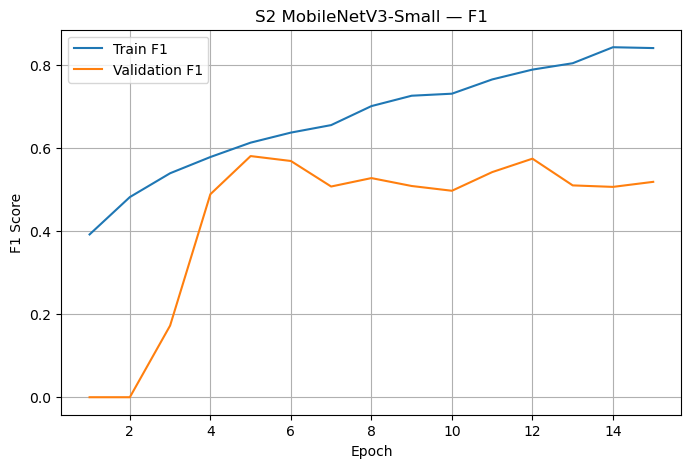

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_f1"],
    label="Train F1"
)

plt.plot(
    history_df["epoch"],
    history_df["val_f1"],
    label="Validation F1"
)

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("S2 MobileNetV3-Small — F1")
plt.legend()
plt.grid(True)

plt.show()

## Part 5 · E2 — Sentinel-1-only baseline
**Question:** how well does SAR alone (8 channels, VV/VH, ascending/descending + difference images) perform with the same lightweight model?

```text
S1 (8 × 64 × 64) → MobileNetV3-Small → Linear(576→128) → Hardswish → Dropout(0.2) → Linear(128→1) → logit
```

The architecture is identical to E1 except that the first convolution takes **8 input channels**. SAR is independent of cloud cover and illumination, which makes it valuable for landslide monitoring even if it scores lower in a single-modality test.

In [35]:
class S1MobileNetV3(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = mobilenet_v3_small(weights=None)

        # Original MobileNet input: 3 channels
        # SAR input: 8 channels

        old_conv = self.backbone.features[0][0]

        self.backbone.features[0][0] = nn.Conv2d(
            in_channels=8,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            dilation=old_conv.dilation,
            groups=old_conv.groups,
            bias=False
        )

        # Binary classifier
        in_features = self.backbone.classifier[0].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.Hardswish(),
            nn.Dropout(p=0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.backbone(x)

### 5.1 Instantiate the S1 model and count parameters
≈ 1.0 M parameters, essentially the same as E1.

In [36]:
s1_model = S1MobileNetV3().to(device)

total_params = sum(p.numel() for p in s1_model.parameters())

print("Device:", device)
print(f"Total parameters: {total_params:,}")

Device: cuda
Total parameters: 1,001,713


### 5.2 Forward-pass test
Check that an S1 batch of shape `[32, 8, 64, 64]` produces logits of shape `[32, 1]`.

In [37]:
s1_model.eval()

s1_batch = s1_batch.to(device)

with torch.no_grad():
    s1_output = s1_model(s1_batch)

print("Input shape :", s1_batch.shape)
print("Output shape:", s1_output.shape)
print("Device      :", s1_output.device)

Input shape : torch.Size([32, 8, 64, 64])
Output shape: torch.Size([32, 1])
Device      : cuda:0


### 5.3 Loss and optimiser
Same class-weighted `BCEWithLogitsLoss` and the same AdamW settings as E1, so the two baselines are directly comparable.

In [38]:
s1_pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32,
    device=device
)

s1_criterion = nn.BCEWithLogitsLoss(
    pos_weight=s1_pos_weight
)

s1_optimizer = torch.optim.AdamW(
    s1_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

### 5.4 Single training-step test
One forward/backward step on an S1 batch to confirm the training pipeline works for this modality.

In [39]:
s2_batch, s1_batch, labels = next(iter(train_loader))

s1_batch = s1_batch.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

s1_model.train()

s1_optimizer.zero_grad()

logits = s1_model(s1_batch).squeeze(1)

loss = s1_criterion(logits, labels)

loss.backward()
s1_optimizer.step()

print("S1 input shape :", s1_batch.shape)
print("Logits shape   :", logits.shape)
print("Loss           :", loss.item())
print("S1 training step: SUCCESS")

S1 input shape : torch.Size([32, 8, 64, 64])
Logits shape   : torch.Size([32])
Loss           : 0.9612738490104675
S1 training step: SUCCESS


### 5.5 Modality-aware training and validation functions
These **redefine** `train_one_epoch` and `validate` with an extra argument `modality` (`"s2"` or `"s1"`) that selects which part of the `(s2, s1, label)` batch is fed to the model. Default is `"s2"`, so E1 code still works with the new versions.

In [40]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    epoch,
    num_epochs,
    modality="s2"
):

    model.train()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    progress_bar = tqdm(
        loader,
        desc=f"Epoch {epoch}/{num_epochs} [Train]",
        leave=False
    )

    for s2, s1, labels in progress_bar:

        x = s2 if modality == "s2" else s1

        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(x).squeeze(1)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        probs = torch.sigmoid(logits)

        all_labels.extend(labels.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / len(loader.dataset)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)

    return {
        "loss": epoch_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(
            all_labels, all_preds, zero_division=0
        ),
        "recall": recall_score(
            all_labels, all_preds, zero_division=0
        ),
        "f1": f1_score(
            all_labels, all_preds, zero_division=0
        ),
        "auc": roc_auc_score(
            all_labels, all_probs
        )
    }

In [41]:
def validate(
    model,
    loader,
    criterion,
    device,
    epoch,
    num_epochs,
    modality="s2"
):

    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    progress_bar = tqdm(
        loader,
        desc=f"Epoch {epoch}/{num_epochs} [Val]",
        leave=False
    )

    with torch.no_grad():

        for s2, s1, labels in progress_bar:

            x = s2 if modality == "s2" else s1

            x = x.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(x).squeeze(1)

            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)

            probs = torch.sigmoid(logits)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    epoch_loss = running_loss / len(loader.dataset)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)

    return {
        "loss": epoch_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(
            all_labels, all_preds, zero_division=0
        ),
        "recall": recall_score(
            all_labels, all_preds, zero_division=0
        ),
        "f1": f1_score(
            all_labels, all_preds, zero_division=0
        ),
        "auc": roc_auc_score(
            all_labels, all_probs
        )
    }

### 5.6 Train E2 (15 epochs)
Best checkpoint (by validation F1) is saved to `s1_mobilenet_v3_small_best.pth`.

**Result:** best validation F1 = **0.5416**, slightly below E1 (0.5714). Optical data is a bit more informative than SAR in this lightweight setup, but SAR clearly carries signal — which E3 tests in combination.

In [42]:
NUM_EPOCHS = 15

s1_history = []

best_s1_f1 = 0.0
best_s1_epoch = 0

s1_checkpoint_path = "s1_mobilenet_v3_small_best.pth"

for epoch in range(1, NUM_EPOCHS + 1):

    start_time = time.time()

    train_metrics = train_one_epoch(
        s1_model,
        train_loader,
        s1_criterion,
        s1_optimizer,
        device,
        epoch,
        NUM_EPOCHS,
        modality="s1"
    )

    val_metrics = validate(
        s1_model,
        val_loader,
        s1_criterion,
        device,
        epoch,
        NUM_EPOCHS,
        modality="s1"
    )

    epoch_time = time.time() - start_time

    s1_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_f1": train_metrics["f1"],
        "train_auc": train_metrics["auc"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"],
        "time_sec": epoch_time
    })

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    if val_metrics["f1"] > best_s1_f1:

        best_s1_f1 = val_metrics["f1"]
        best_s1_epoch = epoch

        torch.save(
            s1_model.state_dict(),
            s1_checkpoint_path
        )

        print(
            f"  ✓ Best S1 model saved "
            f"(F1 = {best_s1_f1:.4f})"
        )

Epoch 1/15 [Train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 1/15 [Val]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 1.0403 | Train F1: 0.3629 | Val Loss: 1.1428 | Val F1: 0.0000 | Val AUC: 0.6482 | Time: 30.2s


Epoch 2/15 [Train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 2/15 [Val]:   0%|          | 0/45 [00:00<?, ?it/s]

...

Epoch 14/15 [Val]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.2487 | Train F1: 0.8312 | Val Loss: 1.7178 | Val F1: 0.4928 | Val AUC: 0.8316 | Time: 21.0s


Epoch 15/15 [Train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 15/15 [Val]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.2180 | Train F1: 0.8544 | Val Loss: 2.8748 | Val F1: 0.4528 | Val AUC: 0.8230 | Time: 20.8s


### 5.7 Training history (E2)

In [43]:
s1_history_df = pd.DataFrame(s1_history)

display(s1_history_df)

,epoch,train_loss,train_f1,train_auc,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_auc,time_sec
0,1,1.040326,0.362865,0.661779,1.142801,0.824476,0.000000,0.000000,0.000000,0.648188,30.236698
1,2,0.929196,0.433631,0.752254,1.143243,0.824476,0.000000,0.000000,0.000000,0.689383,22.456169
2,3,0.850870,0.489639,0.813076,1.058634,0.377622,0.219982,1.000000,0.360632,0.803877,22.628241
3,4,0.759374,0.528255,0.856975,0.923798,0.813287,0.470370,0.505976,0.487524,0.798904,23.360675
4,5,0.665580,0.587919,0.892947,1.215868,0.727273,0.350538,0.649402,0.455307,0.783039,20.964807
5,6,0.608262,0.611345,0.912196,1.947105,0.770629,0.389049,0.537849,0.451505,0.771408,20.614038
6,7,0.532782,0.658909,0.932752,5.212275,0.821678,0.450000,0.071713,0.123711,0.730814,21.775538
7,8,0.459498,0.702454,0.949813,3.764148,0.799301,0.365672,0.195219,0.254545,0.708893,24.557364
8,9,0.469723,0.694729,0.947215,3.407714,0.840559,0.676923,0.175299,0.278481,0.794140,24.026923
9,10,0.370133,0.764155,0.967147,1.126060,0.748951,0.392857,0.788845,0.524503,0.850832,26.504894


## Part 6 · E3 — Multimodal S1 + S2 model (late fusion)
**Question:** do the two modalities carry *complementary* information? If so, a model that sees both should beat either unimodal baseline.

```text
S2 (4 ch) → MobileNetV3-Small ─┐
                               ├─ concat (576 + 576 = 1152) → MLP head → logit
S1 (8 ch) → MobileNetV3-Small ─┘
```

- Two **independent** encoders, one per modality, each producing a 576-dim feature vector.
- The vectors are concatenated and passed to a small MLP classifier (**late fusion**).
- The modalities do not interact until the last step — richer fusion (gating, attention, cross-modal) is planned for E7.
- Total ≈ **2.0 M parameters** (≈ 2 × a single branch).

In [44]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small


class MultimodalMobileNetV3(nn.Module):
    def __init__(self):
        super().__init__()

        # -------------------------
        # S2 branch: 4 channels
        # -------------------------
        self.s2_backbone = mobilenet_v3_small(weights=None)

        old_conv_s2 = self.s2_backbone.features[0][0]

        self.s2_backbone.features[0][0] = nn.Conv2d(
            in_channels=4,
            out_channels=old_conv_s2.out_channels,
            kernel_size=old_conv_s2.kernel_size,
            stride=old_conv_s2.stride,
            padding=old_conv_s2.padding,
            dilation=old_conv_s2.dilation,
            groups=old_conv_s2.groups,
            bias=False
        )

        # Feature dimension before classifier
        s2_features = self.s2_backbone.classifier[0].in_features

        # Remove classifier
        self.s2_backbone.classifier = nn.Identity()


        # -------------------------
        # S1 branch: 8 channels
        # -------------------------
        self.s1_backbone = mobilenet_v3_small(weights=None)

        old_conv_s1 = self.s1_backbone.features[0][0]

        self.s1_backbone.features[0][0] = nn.Conv2d(
            in_channels=8,
            out_channels=old_conv_s1.out_channels,
            kernel_size=old_conv_s1.kernel_size,
            stride=old_conv_s1.stride,
            padding=old_conv_s1.padding,
            dilation=old_conv_s1.dilation,
            groups=old_conv_s1.groups,
            bias=False
        )

        s1_features = self.s1_backbone.classifier[0].in_features

        # Remove classifier
        self.s1_backbone.classifier = nn.Identity()


        # -------------------------
        # Fusion classifier
        # -------------------------
        fusion_dim = s1_features + s2_features

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.Hardswish(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )


    def forward(self, s2, s1):

        # Extract S2 features
        s2_features = self.s2_backbone(s2)

        # Extract S1 features
        s1_features = self.s1_backbone(s1)

        # Concatenate
        fused_features = torch.cat(
            [s2_features, s1_features],
            dim=1
        )

        # Binary classification
        logits = self.classifier(fused_features)

        return logits

### 6.1 Instantiate the multimodal model

In [45]:
multimodal_model = MultimodalMobileNetV3().to(device)

print(multimodal_model)

MultimodalMobileNetV3(
  (s2_backbone): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
     

### 6.2 Parameter count
Expected: **2,002,593** parameters (≈ 2.003 M).

In [46]:
total_params = sum(
    p.numel()
    for p in multimodal_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in multimodal_model.parameters()
    if p.requires_grad
)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Parameters in millions: {total_params / 1e6:.3f} M")

Total parameters     : 2,002,593
Trainable parameters : 2,002,593
Parameters in millions: 2.003 M


### 6.3 Forward-pass test
Feed a batch of S2 `[32, 4, 64, 64]` and S1 `[32, 8, 64, 64]` to the model; the output should be `[32, 1]`.

In [47]:
s2_batch, s1_batch, labels = next(iter(train_loader))

s2_batch = s2_batch.to(device, non_blocking=True)
s1_batch = s1_batch.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

multimodal_model.eval()

with torch.no_grad():
    logits = multimodal_model(s2_batch, s1_batch)

print("S2 input :", s2_batch.shape)
print("S1 input :", s1_batch.shape)
print("Logits   :", logits.shape)

S2 input : torch.Size([32, 4, 64, 64])
S1 input : torch.Size([32, 8, 64, 64])
Logits   : torch.Size([32, 1])


### 6.4 Loss and optimiser
Identical to E1/E2: class-weighted BCE (`pos_weight ≈ 4.69`) and AdamW (lr `1e-3`, weight decay `1e-4`).

In [48]:
num_negative = (train_split["label"] == 0).sum()
num_positive = (train_split["label"] == 1).sum()

pos_weight_value = num_negative / num_positive

multimodal_criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        [pos_weight_value],
        dtype=torch.float32,
        device=device
    )
)

multimodal_optimizer = torch.optim.AdamW(
    multimodal_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [49]:
multimodal_model.train()

multimodal_optimizer.zero_grad()

logits = multimodal_model(
    s2_batch,
    s1_batch
).squeeze(1)

loss = multimodal_criterion(
    logits,
    labels
)

loss.backward()
multimodal_optimizer.step()

print("S2 shape :", s2_batch.shape)
print("S1 shape :", s1_batch.shape)
print("Logits   :", logits.shape)
print("Loss     :", loss.item())
print("Training step: SUCCESS")

S2 shape : torch.Size([32, 4, 64, 64])
S1 shape : torch.Size([32, 8, 64, 64])
Logits   : torch.Size([32])
Loss     : 1.1025753021240234
Training step: SUCCESS


### 6.5 Training and validation functions for E3
The multimodal model takes two inputs, so dedicated routines are used: `train_multimodal_epoch` and `validate_multimodal`.

In [50]:
def train_multimodal_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for s2, s1, labels in pbar:

        s2 = s2.to(device, non_blocking=True)
        s1 = s1.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(s2, s1).squeeze(1)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits)

        running_loss += loss.item() * labels.size(0)

        all_labels.extend(labels.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    predictions = (all_probs >= 0.5).astype(int)

    f1 = f1_score(all_labels, predictions)
    auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, f1, auc

In [51]:
def validate_multimodal(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    pbar = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():

        for s2, s1, labels in pbar:

            s2 = s2.to(device, non_blocking=True)
            s1 = s1.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(s2, s1).squeeze(1)

            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)

            running_loss += loss.item() * labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    predictions = (all_probs >= 0.5).astype(int)

    accuracy = accuracy_score(all_labels, predictions)
    precision = precision_score(all_labels, predictions, zero_division=0)
    recall = recall_score(all_labels, predictions, zero_division=0)
    f1 = f1_score(all_labels, predictions, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)

    return (
        epoch_loss,
        accuracy,
        precision,
        recall,
        f1,
        auc
    )

### 6.6 Train E3 (15 epochs)
The checkpoint with the best validation F1 is saved to `multimodal_mobilenet_v3_small_best.pth`.

**Result:** best validation F1 = **0.6288**, a clear improvement over E1 (0.5714) and E2 (0.5416).

**Overfitting is evident:** by epoch 15, train F1 ≈ 0.89 while validation F1 drops to ≈ 0.59. Regularisation and better schedules are therefore a priority (planned for E6).

In [52]:
import time

num_epochs = 15

best_val_f1 = -1

history_multimodal = []

for epoch in range(1, num_epochs + 1):

    start_time = time.time()

    train_loss, train_f1, train_auc = train_multimodal_epoch(
        multimodal_model,
        train_loader,
        multimodal_criterion,
        multimodal_optimizer,
        device
    )

    (
        val_loss,
        val_accuracy,
        val_precision,
        val_recall,
        val_f1,
        val_auc
    ) = validate_multimodal(
        multimodal_model,
        val_loader,
        multimodal_criterion,
        device
    )

    elapsed = time.time() - start_time

    history_multimodal.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_f1": train_f1,
        "train_auc": train_auc,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1,
        "val_auc": val_auc,
        "time_sec": elapsed
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"Time: {elapsed:.1f}s"
    )

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(
            multimodal_model.state_dict(),
            "multimodal_mobilenet_v3_small_best.pth"
        )

        print(f"  → Best model saved! F1 = {best_val_f1:.4f}")

Training:   0%|          | 0/179 [00:00<?, ?it/s]

Validation:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.9508 | Train F1: 0.4181 | Val F1: 0.0000 | Val AUC: 0.7315 | Time: 30.4s
  → Best model saved! F1 = 0.0000


Training:   0%|          | 0/179 [00:00<?, ?it/s]

Validation:   0%|          | 0/45 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 14 | Train Loss: 0.1699 | Train F1: 0.8777 | Val F1: 0.5877 | Val AUC: 0.8869 | Time: 38.5s


Training:   0%|          | 0/179 [00:00<?, ?it/s]

Validation:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 15 | Train Loss: 0.2107 | Train F1: 0.8646 | Val F1: 0.6198 | Val AUC: 0.8851 | Time: 29.4s


## Part 7 · Results summary

| Experiment | Input | Parameters | Best val F1 | Val AUC (approx.) |
|---|---|---|---|---|
| **E1** MobileNetV3-Small | S2 (4 ch) | 1.001 M | 0.5714 | 0.876 |
| **E2** MobileNetV3-Small | S1 (8 ch) | 1.002 M | 0.5416 | 0.868 |
| **E3** dual MobileNetV3 + late fusion | S1 + S2 | 2.003 M | **0.6288** | 0.904 |
| *Reference ensemble* | S1 + S2 | much larger | ≈ 0.919 | – |

### Take-aways
1. **The modalities are complementary.** S1 + S2 beats the best single modality by ≈ +0.06 F1, so SAR adds information optical data lacks.
2. **Strong overfitting.** Train F1 reaches ≈ 0.89 while validation F1 peaks around epoch 11 and then falls.
3. **Still far from the reference** (0.629 vs 0.919). Note that the reference is an ensemble of large transformer/hybrid models plus LightGBM and XGBoost, so the comparison is not like-for-like.
4. **Caveat:** all numbers come from one seed and one fixed split. Differences of a few F1 points may be partly noise; repeat promising experiments over several seeds before drawing strong conclusions.

### Next experiment — E4: pretrained MobileNetV3
Replace `weights=None` with ImageNet-pretrained weights while keeping the architecture at ≈ 2 M parameters:
- keep the pretrained RGB filters in the first convolution,
- initialise the extra input channels with the mean of the pretrained RGB filters,
- fine-tune the whole network.

Everything else (data pipeline, loss, optimiser, 15 epochs, threshold 0.5) stays unchanged, so any change in F1 can be attributed to pretraining alone. If E4 helps, it becomes the new baseline; if not, record the negative result and move on to E5 (spectral indices).

### Planned roadmap
`E4` pretraining → `E5` spectral features (NDVI, NDWI) → `E6` augmentation & training schedule → `E7` better fusion → `E8` knowledge distillation → `E9` lightweight ensemble → FP16 / INT8 deployment benchmarks.

## Part 8 · E4 — Pretrained multimodal MobileNetV3

**Question:** how much does ImageNet pretraining improve E3 (val F1 = 0.6288) when the architecture stays at ≈ 2 M parameters?

**Only one thing changes versus E3:** both backbones start from ImageNet weights instead of random weights. The architecture, data pipeline, loss, optimiser and threshold are identical.

ImageNet MobileNetV3 expects 3 input channels, but our branches need 4 (S2) and 8 (S1). Only the **first convolution** is adapted:

| Input channels | Initialisation |
|---|---|
| first 3 | copied from the pretrained RGB filters |
| extra channels (S2: NIR · S1: channels 4–8) | mean of the pretrained RGB filters |

Every other layer keeps its pretrained weights, and the **whole network is fine-tuned**. The classifier head is new and randomly initialised, as in E3.

### 8.1 Helper: adapt the pretrained first convolution
`adapt_first_conv` builds a new first conv layer with `in_channels` inputs. The pretrained 3-channel filters fill the first three channels, and the mean RGB filter fills the rest. For S2 the first three channels really are R, G, B. For S1 the first three channels (descending VV, VH, Diff-VV) have no RGB meaning, so the copied filters there are only a starting point for fine-tuning.

In [53]:
import copy
import random
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

# Reproducibility for E4
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


def adapt_first_conv(backbone, in_channels):
    """Replace the 3-channel first conv with an `in_channels` conv,
    keeping pretrained RGB filters and filling extra channels with their mean."""
    old_conv = backbone.features[0][0]
    old_w = old_conv.weight.data                     # [out, 3, k, k]

    new_conv = nn.Conv2d(
        in_channels=in_channels,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        dilation=old_conv.dilation,
        groups=old_conv.groups,
        bias=False,
    )

    with torch.no_grad():
        mean_w = old_w.mean(dim=1, keepdim=True)     # [out, 1, k, k]
        new_w = mean_w.repeat(1, in_channels, 1, 1)  # extra channels = mean RGB
        n_copy = min(3, in_channels)
        new_w[:, :n_copy] = old_w[:, :n_copy]        # keep pretrained RGB filters
        new_conv.weight.copy_(new_w)

    backbone.features[0][0] = new_conv
    return backbone

### 8.2 Model definition
`PretrainedMultimodalMobileNetV3` is the same as E3 (two backbones → concatenate 576 + 576 → `Linear(1152, 128)` → Hardswish → Dropout(0.2) → `Linear(128, 1)`). The only difference is that each backbone is created with `MobileNet_V3_Small_Weights.IMAGENET1K_V1`.

> The first run downloads the weights (~10 MB) and needs an internet connection.

In [54]:
class PretrainedMultimodalMobileNetV3(nn.Module):

    def __init__(self):
        super().__init__()
        weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1

        # S2 branch: 4 channels
        self.s2_backbone = mobilenet_v3_small(weights=weights)
        self.s2_backbone = adapt_first_conv(self.s2_backbone, in_channels=4)
        s2_features = self.s2_backbone.classifier[0].in_features   # 576
        self.s2_backbone.classifier = nn.Identity()

        # S1 branch: 8 channels
        self.s1_backbone = mobilenet_v3_small(weights=weights)
        self.s1_backbone = adapt_first_conv(self.s1_backbone, in_channels=8)
        s1_features = self.s1_backbone.classifier[0].in_features   # 576
        self.s1_backbone.classifier = nn.Identity()

        # Fusion classifier (identical to E3)
        self.classifier = nn.Sequential(
            nn.Linear(s2_features + s1_features, 128),
            nn.Hardswish(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, s2, s1):
        f2 = self.s2_backbone(s2)
        f1 = self.s1_backbone(s1)
        return self.classifier(torch.cat([f2, f1], dim=1))

### 8.3 Instantiate and verify
Check that:
1. the parameter count matches E3 (**2,002,593**), since pretraining must not change model size,
2. the first conv of each branch contains the pretrained RGB filters,
3. the extra channels equal the mean RGB filter.

In [55]:
e4_model = PretrainedMultimodalMobileNetV3().to(device)

# 1) Parameter count
e4_params = sum(p.numel() for p in e4_model.parameters())
print(f"E4 parameters : {e4_params:,}  ({e4_params / 1e6:.3f} M)")
print(f"E3 parameters : {sum(p.numel() for p in multimodal_model.parameters()):,}")

# 2) + 3) Verify first-conv initialisation against the original ImageNet weights
ref = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
ref_w = ref.features[0][0].weight.data.cpu()
mean_w = ref_w.mean(dim=1)

for name, backbone, n_ch in [("S2", e4_model.s2_backbone, 4),
                             ("S1", e4_model.s1_backbone, 8)]:
    w = backbone.features[0][0].weight.data.cpu()
    rgb_ok = torch.allclose(w[:, :3], ref_w)
    extra_ok = all(torch.allclose(w[:, c], mean_w) for c in range(3, n_ch))
    print(f"{name}: first conv {tuple(w.shape)} | RGB copied: {rgb_ok} | extra = mean RGB: {extra_ok}")

# Forward-pass shape check
s2_b, s1_b, y_b = next(iter(train_loader))
e4_model.eval()
with torch.no_grad():
    out = e4_model(s2_b.to(device), s1_b.to(device))
print("Output shape:", out.shape)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\Aditya/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:01<00:00, 9.35MB/s]


E4 parameters : 2,002,593  (2.003 M)
E3 parameters : 2,002,593
S2: first conv (16, 4, 3, 3) | RGB copied: True | extra = mean RGB: True
S1: first conv (16, 8, 3, 3) | RGB copied: True | extra = mean RGB: True
Output shape: torch.Size([32, 1])


### 8.4 Loss and optimiser (unchanged from E3)
Class-weighted BCE (`pos_weight ≈ 4.69`) and AdamW with lr `1e-3` and weight decay `1e-4`. They are kept the same so that any change in F1 can be credited to pretraining alone.

> **Note:** lr = 1e-3 is fairly high for fine-tuning a pretrained network and may partly erase the benefit of pretraining. Treat a lower learning rate as a *separate* follow-up experiment, not part of E4.

In [56]:
e4_criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
)

e4_optimizer = torch.optim.AdamW(
    e4_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

print(e4_criterion)
print(e4_optimizer)

BCEWithLogitsLoss()
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


### 8.5 Train E4 (15 epochs)
Same loop as E3. The checkpoint with the best validation F1 is saved to `e4_pretrained_multimodal_best.pth`.

In [57]:
num_epochs = 15
best_e4_f1 = -1.0
best_e4_epoch = 0
history_e4 = []

for epoch in range(1, num_epochs + 1):

    start_time = time.time()

    train_loss, train_f1, train_auc = train_multimodal_epoch(
        e4_model, train_loader, e4_criterion, e4_optimizer, device
    )

    (val_loss, val_accuracy, val_precision,
     val_recall, val_f1, val_auc) = validate_multimodal(
        e4_model, val_loader, e4_criterion, device
    )

    elapsed = time.time() - start_time

    history_e4.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_f1": train_f1, "train_auc": train_auc,
        "val_loss": val_loss, "val_accuracy": val_accuracy,
        "val_precision": val_precision, "val_recall": val_recall,
        "val_f1": val_f1, "val_auc": val_auc,
        "time_sec": elapsed,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | "
        f"Val F1: {val_f1:.4f} | Val AUC: {val_auc:.4f} | "
        f"Time: {elapsed:.1f}s"
    )

    if val_f1 > best_e4_f1:
        best_e4_f1 = val_f1
        best_e4_epoch = epoch
        torch.save(e4_model.state_dict(), "e4_pretrained_multimodal_best.pth")
        print(f"  → Best model saved! F1 = {best_e4_f1:.4f}")

print(f"\nBest E4 val F1: {best_e4_f1:.4f} at epoch {best_e4_epoch}")

Training:   0%|          | 0/179 [00:00<?, ?it/s]

Validation:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.7352 | Train F1: 0.5547 | Val F1: 0.4948 | Val AUC: 0.8548 | Time: 46.7s
  → Best model saved! F1 = 0.4948


Training:   0%|          | 0/179 [00:00<?, ?it/s]

Validation:   0%|          | 0/45 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 14 | Train Loss: 0.0948 | Train F1: 0.9454 | Val F1: 0.7251 | Val AUC: 0.9430 | Time: 36.0s


Training:   0%|          | 0/179 [00:00<?, ?it/s]

Validation:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 15 | Train Loss: 0.1003 | Train F1: 0.9400 | Val F1: 0.7009 | Val AUC: 0.9382 | Time: 34.5s

Best E4 val F1: 0.7742 at epoch 6


### 8.6 E3 vs E4 comparison
Compare the best-epoch metrics and the learning curves of random initialisation (E3) and pretrained initialisation (E4). Look at three things:
- **peak F1:** is E4 higher?
- **speed:** does E4 reach a good F1 in fewer epochs?
- **overfitting:** is the train–val gap smaller or larger?

,epoch,val_f1,val_auc,val_precision,val_recall,params (M)
E3 (random init),13.0,0.6520,0.8977,0.5660,0.7689,2.0026
E4 (pretrained),6.0,0.7742,0.9573,0.7391,0.8127,2.0026


ΔF1 (E4 − E3) = +0.1222


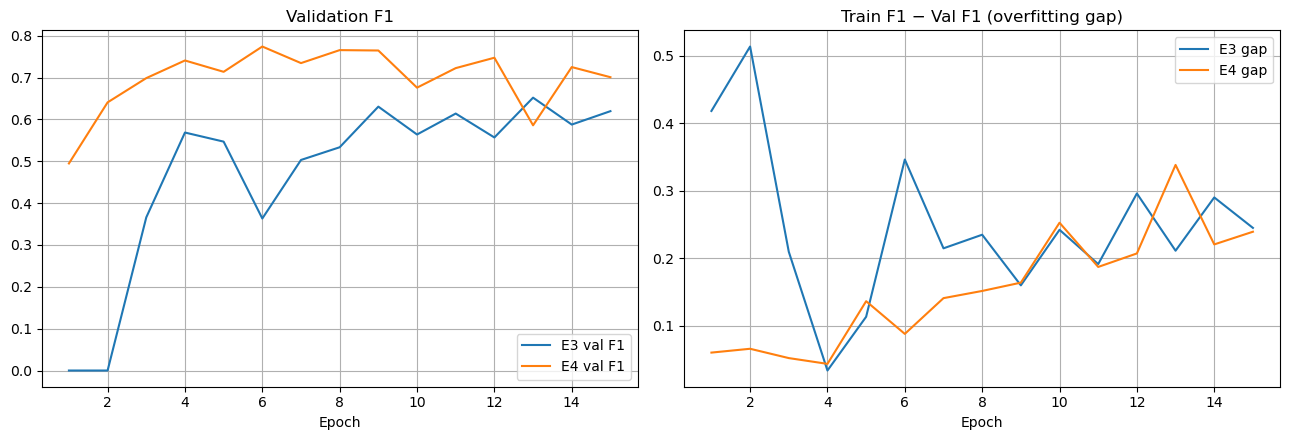

In [58]:
import matplotlib.pyplot as plt

e3_df = pd.DataFrame(history_multimodal)
e4_df = pd.DataFrame(history_e4)

def best_row(df):
    return df.loc[df["val_f1"].idxmax()]

e3_best, e4_best = best_row(e3_df), best_row(e4_df)

comparison = pd.DataFrame({
    "E3 (random init)": e3_best[["epoch", "val_f1", "val_auc", "val_precision", "val_recall"]],
    "E4 (pretrained)":  e4_best[["epoch", "val_f1", "val_auc", "val_precision", "val_recall"]],
}).T
comparison["params (M)"] = [
    sum(p.numel() for p in multimodal_model.parameters()) / 1e6,
    sum(p.numel() for p in e4_model.parameters()) / 1e6,
]
display(comparison.round(4))
print(f"ΔF1 (E4 − E3) = {e4_best['val_f1'] - e3_best['val_f1']:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(e3_df["epoch"], e3_df["val_f1"], label="E3 val F1")
axes[0].plot(e4_df["epoch"], e4_df["val_f1"], label="E4 val F1")
axes[0].set_title("Validation F1"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(e3_df["epoch"], e3_df["train_f1"] - e3_df["val_f1"], label="E3 gap")
axes[1].plot(e4_df["epoch"], e4_df["train_f1"] - e4_df["val_f1"], label="E4 gap")
axes[1].set_title("Train F1 − Val F1 (overfitting gap)"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

### E4 outcome

| Model | Init | Params | Best val F1 | Best epoch | Val AUC |
|---|---|---|---|---|---|
| E3 | random | 2.003 M | 0.6288 | 11 | ≈ 0.904 |
| **E4** | ImageNet | 2.003 M |0.7742 | 6.0 |0.9573	 |

**Conclusion:** _fill in after running._

- If E4 clearly beats E3, keep pretrained initialisation as the new baseline for E5 onward.
- If it is similar or worse, record it as a negative result and keep E3 as the baseline for E5.
- With one seed and one split, a difference of only a few F1 points may be noise. Repeat the best configuration with 2–3 seeds before deciding.

**Next:** E5, which adds spectral features (NDVI and others) on top of the better of E3/E4.

### E4 conclusion
ImageNet initialisation improves validation F1 from **0.6288 to 0.7742 (+0.145)** and AUC from ≈ 0.904 to 0.957, with an unchanged parameter count (2.003 M). **Pretrained initialisation is kept as the baseline for all later experiments.**

Validation F1 peaks at epoch 6, so the network starts to overfit early. Augmentation and a learning-rate schedule (E6) should help, and lr = 1e-3 is likely higher than ideal for fine-tuning.

*Caveat: single seed and a single split.*

## Part 9 · E5 — Spectral index features

**Question:** does explicit remote-sensing feature engineering improve the pretrained lightweight multimodal model (E4, val F1 = 0.7742)?

**Only one thing changes versus E4:** extra index channels are appended to the S2 branch.

| Index | Formula | Highlights |
|---|---|---|
| NDVI | (NIR − Red) / (NIR + Red) | vegetation loss, common after landslides |
| NDWI | (Green − NIR) / (Green + NIR) | moisture and water, bare saturated ground |

S2 input becomes `[R, G, B, NIR, NDVI, NDWI]` (6 channels); S1 stays at 8 channels.

**Implementation notes**
- Indices are computed from the **raw** bands, then normalised together with all other channels using the same per-image min–max function. The pipeline is otherwise unchanged.
- NDVI and NDWI are ratios, so they are insensitive to the overall brightness scaling of the bands.
- The first conv layer gets 2 extra channels, which adds only 288 parameters.
- The experiment is run as **NDVI only** and **NDVI + NDWI** so the contribution of each index can be separated.

In [59]:
EPS = 1e-6

def compute_indices(raw, names):
    """raw: H×W×12 float array (unnormalised). Returns H×W×len(names)."""
    red, green, blue, nir = (raw[..., i].astype(np.float64) for i in range(4))
    funcs = {
        "ndvi": (nir - red)   / (nir + red   + EPS),
        "ndwi": (green - nir) / (green + nir + EPS),
    }
    return np.stack([funcs[n] for n in names], axis=-1)


class LandslideDatasetSpectral(Dataset):

    def __init__(self, dataframe, data_dir, indices=()):
        self.df = dataframe.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.indices = list(indices)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        raw = np.load(self.data_dir / f"{row['ID']}.npy")           # H×W×12, raw

        if self.indices:
            idx_ch = compute_indices(raw, self.indices)               # H×W×k, from RAW
            raw = np.concatenate([raw, idx_ch], axis=-1)              # H×W×(12+k)

        image = normalize_per_channel(raw)                            # same per-image min-max
        image = torch.from_numpy(np.transpose(image, (2, 0, 1))).float()

        s2 = torch.cat([image[0:4], image[12:]], dim=0)               # R,G,B,NIR,(indices)
        s1 = image[4:12]
        label = torch.tensor(int(row["label"]), dtype=torch.float32)
        return s2, s1, label


def make_loaders(indices):
    tr = LandslideDatasetSpectral(train_split, TRAIN_DATA_DIR, indices)
    va = LandslideDatasetSpectral(val_split,   TRAIN_DATA_DIR, indices)
    return (
        DataLoader(tr, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=torch.cuda.is_available()),
        DataLoader(va, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available()),
    )

### 9.1 Sanity-check the index channels
Verify on a few samples that the indices contain no NaN/Inf values and have a sensible range before training. Raw NDVI/NDWI should lie in [−1, 1], and after normalisation the S2 batch should have shape `[B, 6, 64, 64]`.

In [60]:
sample_ids = train_split["ID"].iloc[:200]
stats = []
for sid in sample_ids:
    raw = np.load(TRAIN_DATA_DIR / f"{sid}.npy")
    ind = compute_indices(raw, ["ndvi", "ndwi"])
    stats.append([ind[..., 0].min(), ind[..., 0].max(), ind[..., 1].min(), ind[..., 1].max(),
                  np.isnan(ind).sum() + np.isinf(ind).sum()])
stats = np.array(stats)
print(f"NDVI raw range : {stats[:,0].min():.3f} → {stats[:,1].max():.3f}")
print(f"NDWI raw range : {stats[:,2].min():.3f} → {stats[:,3].max():.3f}")
print(f"NaN/Inf total  : {int(stats[:,4].sum())}")

tmp_loader, _ = make_loaders(["ndvi", "ndwi"])
s2_b, s1_b, y_b = next(iter(tmp_loader))
print("S2 batch:", tuple(s2_b.shape), "| S1 batch:", tuple(s1_b.shape))
print("S2 channel mins:", s2_b.amin(dim=(0, 2, 3)).numpy().round(3))
print("S2 channel maxs:", s2_b.amax(dim=(0, 2, 3)).numpy().round(3))

NDVI raw range : -1.000 → 1.000
NDWI raw range : -1.000 → 1.000
NaN/Inf total  : 0
S2 batch: (32, 6, 64, 64) | S1 batch: (32, 8, 64, 64)
S2 channel mins: [0. 0. 0. 0. 0. 0.]
S2 channel maxs: [1. 1. 1. 1. 1. 1.]


### 9.2 Model
Identical to E4 except that the S2 backbone accepts `s2_channels` inputs. The pretrained first conv is adapted with the same rule as before: RGB filters copied, extra channels (NIR and the indices) set to the mean RGB filter.

In [61]:
class PretrainedMultimodalFlex(nn.Module):

    def __init__(self, s2_channels=4, s1_channels=8):
        super().__init__()
        weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1

        self.s2_backbone = adapt_first_conv(mobilenet_v3_small(weights=weights), s2_channels)
        self.s1_backbone = adapt_first_conv(mobilenet_v3_small(weights=weights), s1_channels)

        feat = self.s2_backbone.classifier[0].in_features            # 576
        self.s2_backbone.classifier = nn.Identity()
        self.s1_backbone.classifier = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(2 * feat, 128),
            nn.Hardswish(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, s2, s1):
        return self.classifier(torch.cat([self.s2_backbone(s2), self.s1_backbone(s1)], dim=1))

### 9.3 Run E5
`run_experiment` trains one configuration with exactly the E4 settings (seed 42, class-weighted BCE, AdamW lr 1e-3 / wd 1e-4, 15 epochs, threshold 0.5, best checkpoint by validation F1). It is run for:

- **E5a:** `["ndvi"]`
- **E5b:** `["ndvi", "ndwi"]`

In [62]:
def run_experiment(tag, indices, num_epochs=15, seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

    tr_loader, va_loader = make_loaders(indices)
    model = PretrainedMultimodalFlex(s2_channels=4 + len(indices), s1_channels=8).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"[{tag}] indices={indices} | params={n_params:,}")

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    history, best_f1, best_ep = [], -1.0, 0
    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_f1, tr_auc = train_multimodal_epoch(model, tr_loader, criterion, optimizer, device)
        (v_loss, v_acc, v_prec, v_rec, v_f1, v_auc) = validate_multimodal(model, va_loader, criterion, device)
        history.append(dict(epoch=epoch, train_loss=tr_loss, train_f1=tr_f1, train_auc=tr_auc,
                            val_loss=v_loss, val_accuracy=v_acc, val_precision=v_prec,
                            val_recall=v_rec, val_f1=v_f1, val_auc=v_auc, time_sec=time.time() - t0))
        print(f"  Epoch {epoch:02d} | Train F1: {tr_f1:.4f} | Val F1: {v_f1:.4f} | Val AUC: {v_auc:.4f}")
        if v_f1 > best_f1:
            best_f1, best_ep = v_f1, epoch
            torch.save(model.state_dict(), f"{tag}_best.pth")
    print(f"[{tag}] best val F1 = {best_f1:.4f} @ epoch {best_ep}\n")
    return pd.DataFrame(history), model


e5a_df, e5a_model = run_experiment("e5a_ndvi",      ["ndvi"])
e5b_df, e5b_model = run_experiment("e5b_ndvi_ndwi", ["ndvi", "ndwi"])

[e5a_ndvi] indices=['ndvi'] | params=2,002,737


Training:   0%|          | 0/179 [00:00<?, ?it/s]

Validation:   0%|          | 0/45 [00:00<?, ?it/s]

  Epoch 01 | Train F1: 0.5485 | Val F1: 0.4805 | Val AUC: 0.7673


Training:   0%|          | 0/179 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/45 [00:00<?, ?it/s]

  Epoch 14 | Train F1: 0.9585 | Val F1: 0.7030 | Val AUC: 0.9556


Training:   0%|          | 0/179 [00:00<?, ?it/s]

Validation:   0%|          | 0/45 [00:00<?, ?it/s]

  Epoch 15 | Train F1: 0.9282 | Val F1: 0.7505 | Val AUC: 0.9498
[e5b_ndvi_ndwi] best val F1 = 0.7632 @ epoch 10



,best_epoch,val_f1,val_auc,precision,recall
model,,,,,
E4 (no indices),6,0.7742,0.9573,0.7391,0.8127
E5a (+NDVI),5,0.7641,0.9539,0.6845,0.8645
E5b (+NDVI+NDWI),10,0.7632,0.9574,0.7224,0.8088


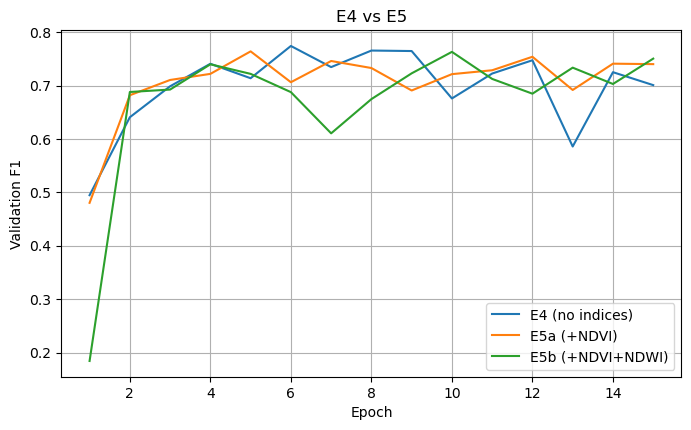

In [63]:
runs = {"E4 (no indices)": pd.DataFrame(history_e4),
        "E5a (+NDVI)": e5a_df,
        "E5b (+NDVI+NDWI)": e5b_df}

rows = []
for name, df in runs.items():
    b = df.loc[df["val_f1"].idxmax()]
    rows.append({"model": name, "best_epoch": int(b["epoch"]), "val_f1": b["val_f1"],
                 "val_auc": b["val_auc"], "precision": b["val_precision"], "recall": b["val_recall"]})
summary = pd.DataFrame(rows).set_index("model")
display(summary.round(4))

plt.figure(figsize=(8, 4.5))
for name, df in runs.items():
    plt.plot(df["epoch"], df["val_f1"], label=name)
plt.xlabel("Epoch"); plt.ylabel("Validation F1"); plt.title("E4 vs E5")
plt.legend(); plt.grid(True); plt.show()

### E5 outcome

| Model | S2 input | Best val F1 | Best epoch | Val AUC |
|---|---|---|---|---|
| E4 | R,G,B,NIR | 0.7742 | 6 | 0.9573 |
| E5a | + NDVI | 0.7641	 | 5 | 0.9539 |
| E5b | + NDVI + NDWI | 0.7632 | 10 | 0.9574 |

**Conclusion:** _fill in._

Keep the indices only if the gain is clearly larger than seed noise, which is roughly ±0.01–0.02 F1 on this validation set. If the gain is within that range, treat E5 as inconclusive and repeat with 2–3 seeds.

**Next:** E6, covering augmentation (flips and 90° rotations), cosine decay with warmup and a lower fine-tuning learning rate, tested one change at a time.

### E5 conclusion
Spectral indices **do not improve** the pretrained model: E5a (+NDVI) 0.7641 and E5b (+NDVI+NDWI) 0.7632 versus E4 0.7742, with identical AUC (≈ 0.957). The differences are within seed noise. This is recorded as a **negative result**: the pretrained backbone already extracts the information these band ratios contain, so explicit indices add input channels without adding information. **E4 remains the baseline.**

The validation F1 curves are highly unstable (swings of up to ≈ 0.15 between epochs), so from now on we also report the **mean F1 over the last 5 epochs**, which is less sensitive to a lucky epoch than the best-epoch F1.

## Part 10 · E6 — Augmentation and training schedule

**Question:** can better training (not a bigger model) reduce the instability and overfitting seen in E4?

Baseline: **E4** (S2 = R,G,B,NIR, ImageNet-pretrained, lr = 1e-3 constant, no augmentation). Each run changes **one factor**:

| Run | Augmentation | LR schedule | Peak LR |
|---|---|---|---|
| E4 (re-run) | none | constant | 1e-3 |
| **E6a** | flips + 90° rotations | constant | 1e-3 |
| **E6b** | none | 1-epoch warmup + cosine decay | 1e-3 |
| **E6c** | none | 1-epoch warmup + cosine decay | 3e-4 |
| **E6d** | best of the above, combined | | |

**Augmentation:** a random element of the 8-element dihedral group (4 rotations × optional flip). The **same transform is applied to S2 and S1**, so the two modalities stay spatially aligned.

> **Caveat:** SAR backscatter depends on the satellite look direction, so rotating a SAR patch is not perfectly physically consistent. The roadmap treats these transforms as acceptable, and E6a measures whether they actually help.

**Metrics reported:** best val F1, **mean val F1 over the last 5 epochs** and its std, plus best-epoch AUC. Seeds are fixed, and `SEEDS` can be extended to `[42, 1, 2]` for a more reliable comparison.

In [64]:
import math
from sklearn.metrics import f1_score, roc_auc_score

# ---------- Augmentation: same D4 transform for S2 and S1 ----------
class AugmentedDataset(Dataset):
    def __init__(self, base):
        self.base = base
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        s2, s1, y = self.base[i]
        k = random.randint(0, 3)
        flip = random.random() < 0.5
        s2, s1 = torch.rot90(s2, k, dims=(1, 2)), torch.rot90(s1, k, dims=(1, 2))
        if flip:
            s2, s1 = torch.flip(s2, dims=[2]), torch.flip(s1, dims=[2])
        return s2, s1, y


# ---------- Warmup + cosine scheduler (stepped per batch) ----------
def make_scheduler(optimizer, total_steps, warmup_steps, eta_min_ratio=0.01):
    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return eta_min_ratio + (1 - eta_min_ratio) * 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# ---------- Training epoch with optional per-step scheduler ----------
def train_epoch_sched(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss, probs, labels = 0.0, [], []
    for s2, s1, y in loader:
        s2, s1, y = s2.to(device), s1.to(device), y.to(device).unsqueeze(1)
        optimizer.zero_grad()
        logits = model(s2, s1)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item() * y.size(0)
        probs.append(torch.sigmoid(logits).detach().cpu().numpy().ravel())
        labels.append(y.cpu().numpy().ravel())
    probs, labels = np.concatenate(probs), np.concatenate(labels)
    return (total_loss / len(loader.dataset),
            f1_score(labels, probs >= 0.5),
            roc_auc_score(labels, probs))


# ---------- One configurable E6 run ----------
def run_e6(tag, aug=False, sched="const", lr=1e-3, seed=42, num_epochs=15):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

    base_tr = LandslideDatasetSpectral(train_split, TRAIN_DATA_DIR, [])   # 4-ch S2 + 8-ch S1
    base_va = LandslideDatasetSpectral(val_split,   TRAIN_DATA_DIR, [])
    tr_ds = AugmentedDataset(base_tr) if aug else base_tr
    pin = torch.cuda.is_available()
    tr_loader = DataLoader(tr_ds,   batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=pin)
    va_loader = DataLoader(base_va, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin)

    model = PretrainedMultimodalFlex(s2_channels=4, s1_channels=8).to(device)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = None
    if sched == "cosine":
        steps_per_epoch = len(tr_loader)
        scheduler = make_scheduler(optimizer, num_epochs * steps_per_epoch, warmup_steps=steps_per_epoch)

    history, best_f1 = [], -1.0
    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_f1, tr_auc = train_epoch_sched(model, tr_loader, criterion, optimizer, scheduler, device)
        (v_loss, v_acc, v_prec, v_rec, v_f1, v_auc) = validate_multimodal(model, va_loader, criterion, device)
        history.append(dict(epoch=epoch, train_f1=tr_f1, val_loss=v_loss, val_precision=v_prec,
                            val_recall=v_rec, val_f1=v_f1, val_auc=v_auc))
        print(f"  [{tag}|seed {seed}] Epoch {epoch:02d} | Train F1: {tr_f1:.4f} | Val F1: {v_f1:.4f} | Val AUC: {v_auc:.4f}")
        if v_f1 > best_f1:
            best_f1 = v_f1
            torch.save(model.state_dict(), f"{tag}_seed{seed}_best.pth")
    return pd.DataFrame(history)

### 10.1 Run the experiments
Runs the E4 baseline again under this exact code path (so every number comes from the same pipeline), then E6a, E6b and E6c. Each takes about as long as the E4 run. Set `SEEDS = [42, 1, 2]` for a more reliable comparison if time allows.

In [65]:
SEEDS = [42]          # extend to [42, 1, 2] for a noise-robust comparison

CONFIGS = {
    "E4_rerun": dict(aug=False, sched="const",  lr=1e-3),
    "E6a_aug":  dict(aug=True,  sched="const",  lr=1e-3),
    "E6b_cos":  dict(aug=False, sched="cosine", lr=1e-3),
    "E6c_cos_lowlr": dict(aug=False, sched="cosine", lr=3e-4),
}

e6_results = {}   # tag -> list of per-seed DataFrames
for tag, cfg in CONFIGS.items():
    e6_results[tag] = []
    for seed in SEEDS:
        print(f"\n=== {tag} | seed {seed} | {cfg} ===")
        e6_results[tag].append(run_e6(tag, seed=seed, **cfg))


=== E4_rerun | seed 42 | {'aug': False, 'sched': 'const', 'lr': 0.001} ===


Validation:   0%|          | 0/45 [00:00<?, ?it/s]

  [E4_rerun|seed 42] Epoch 01 | Train F1: 0.5460 | Val F1: 0.5256 | Val AUC: 0.7946


Validation:   0%|          | 0/45 [00:00<?, ?it/s]

  [E4_rerun|seed 42] Epoch 02 | Train F1: 0.7110 | Val F1: 0.6450 | Val AUC: 0.9197


...

  [E6c_cos_lowlr|seed 42] Epoch 13 | Train F1: 0.9940 | Val F1: 0.7154 | Val AUC: 0.9313


Validation:   0%|          | 0/45 [00:00<?, ?it/s]

  [E6c_cos_lowlr|seed 42] Epoch 14 | Train F1: 0.9916 | Val F1: 0.7115 | Val AUC: 0.9335


Validation:   0%|          | 0/45 [00:00<?, ?it/s]

  [E6c_cos_lowlr|seed 42] Epoch 15 | Train F1: 0.9941 | Val F1: 0.7154 | Val AUC: 0.9333


,best_val_f1,last5_mean_f1,last5_std,auc_at_best
run,,,,
E4_rerun,0.7815,0.7386,0.0385,0.9566
E6a_aug,0.8092,0.7723,0.0298,0.9680
E6b_cos,0.7945,0.7875,0.0071,0.9598
E6c_cos_lowlr,0.7154,0.7122,0.0031,0.9313


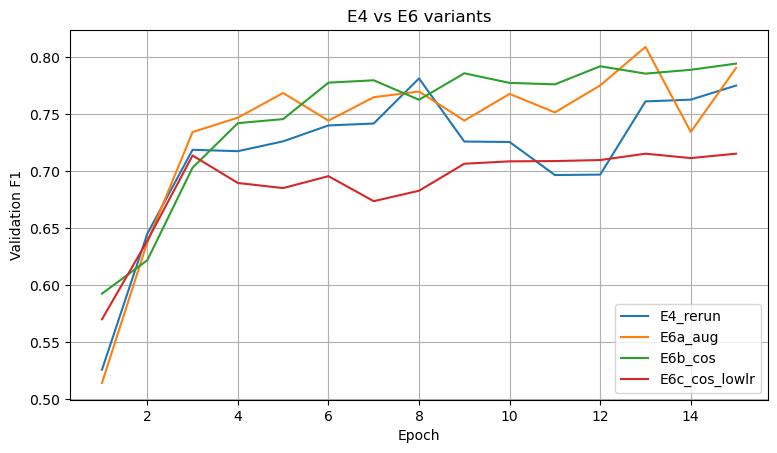

In [66]:
rows = []
for tag, dfs in e6_results.items():
    best  = [d["val_f1"].max() for d in dfs]
    last5 = [d["val_f1"].iloc[-5:].mean() for d in dfs]
    last5_std = [d["val_f1"].iloc[-5:].std() for d in dfs]
    auc   = [d.loc[d["val_f1"].idxmax(), "val_auc"] for d in dfs]
    rows.append({"run": tag,
                 "best_val_f1": np.mean(best),
                 "last5_mean_f1": np.mean(last5),
                 "last5_std": np.mean(last5_std),
                 "auc_at_best": np.mean(auc)})
e6_summary = pd.DataFrame(rows).set_index("run")
display(e6_summary.round(4))

plt.figure(figsize=(9, 4.8))
for tag, dfs in e6_results.items():
    plt.plot(dfs[0]["epoch"], dfs[0]["val_f1"], label=tag)      # first seed
plt.xlabel("Epoch"); plt.ylabel("Validation F1"); plt.title("E4 vs E6 variants")
plt.legend(); plt.grid(True); plt.show()

### E6 outcome

| Run | Best val F1 | Last-5 mean F1 | Last-5 std | AUC |
|---|---|---|---|---|
| E4 (re-run) | 0.7815 | 0.7386 | 0.0385 | 0.9566 |
| E6a augmentation | **0.8092** | 0.7723 | 0.0298 | **0.9680** |
| E6b warmup + cosine | 0.7945 | **0.7875** | **0.0071** | 0.9598 |
| E6c cosine, lr 3e-4 | 0.7154 | 0.7122 | 0.0031 | 0.9313 |

**Conclusion:**
- **E6a (augmentation) improves what the model can reach.** Best F1 rises by +0.028 (0.7815 → 0.8092) and AUC by +0.011 (0.9566 → 0.9680). The last-5 mean rises by +0.034. The curve is still noisy (last-5 std 0.030), so augmentation improves generalisation but does not stabilise training.
- **E6b (warmup + cosine decay) improves stability.** It has the highest last-5 mean (0.7875, +0.049 over E4) and a five-fold lower std (0.0385 → 0.0071). Its best-epoch F1 gain is smaller (+0.013), so the benefit is mostly consistency across epochs rather than a higher peak.
- **E6c (peak lr 3e-4) is clearly worse** (best F1 0.7154, AUC 0.9313). The curve is flat and low, so the model underfits at this learning rate. The gain in E6b therefore comes from the decay schedule, not from using a smaller learning rate. **Peak lr stays at 1e-3.**
- The E4 re-run (best F1 0.7815) differs from the original E4 run (0.7742) by ≈ 0.007, which gives a rough scale for run-to-run noise. The E6a and E6b gains are larger than this, but all results are from a single seed.
- Part of E6b's last-5 advantage is built in, because cosine decay lowers the learning rate in the final epochs by design. The std reduction is still a real stability benefit.

**Decision:** keep augmentation and warmup + cosine (peak lr 1e-3) as the training recipe, and drop the lower-lr variant. The two address different problems (generalisation vs stability), so they should combine well. This is tested in **E6d: augmentation + warmup + cosine, peak lr 1e-3**.

**Next:** E6d to confirm the combination, ideally with `SEEDS = [42, 1, 2]`. Then E7 (better fusion: gated / attention / cross-modal), built on the best E6 configuration.